# Stack Overflow Retention, causal estimates

The EDA notebook reported a naive D30 lift of +8.0 pp for getting an answer within 24 hours of posting (control 19.1% vs treated 27.1%). That number is wrong as a causal estimate. People who write good questions get faster answers and would retain anyway, so a chunk of the 8.0 pp is selection on question quality, not the effect of the answer.

This notebook runs four estimators side by side on the same treatment and tries to isolate the part of the lift that is plausibly causal.

1. Controlled OLS, a linear probability model that throws every observable feature into the regression and reads off the treatment coefficient.
2. IPW, where each observation is reweighted by the inverse of its estimated treatment probability, then a weighted regression of outcome on treatment.
3. Propensity-score stratification, binning users into deciles by treatment propensity and averaging within-decile mean differences.
4. 2SLS using the hour-of-day-of-posting instrument from sql-05.

If they all land roughly in the same place, the story is consistent. If they disagree, we have something interesting to write about in the case study.

All of this is repeated for the D180 outcome on the observable subset.

In [1]:
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS

import db_dtypes  # noqa: F401

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = '../data/processed'

## 1. Load and set up

Pre-compute a couple of feature transforms (log body length, year-level cohort) so the formula strings stay readable. The covariate set is the same across methods, except the IV drops hour_of_day_utc as a covariate, since hour is the source of the instrument and including it would absorb the variation the IV needs.

In [2]:
df = pq.read_table(f'{DATA_DIR}/master.parquet').to_pandas()

# Pre-compute transforms
df['log_body_length'] = np.log(df['body_length'].clip(lower=1))
df['cohort_year'] = pd.to_datetime(df['cohort_month']).dt.year

# Cast Int64 -> float for regression compatibility (linearmodels and statsmodels
# both prefer real numeric dtypes; the pandas extension Int64 with NA support
# trips up formulaic).
for col in ['active_d30', 'active_d180', 'got_answer_within_24h', 'got_answer_within_1h',
             'got_any_answer', 'has_code_block', 'has_link', 'has_image', 'is_weekend',
             'title_length', 'num_tags', 'hour_of_day_utc', 'day_of_week',
             'd180_observable']:
    df[col] = df[col].astype(float)

print(f'Loaded master.parquet: {len(df):,} rows x {df.shape[1]} cols')
print(f'Treatment: got_answer_within_24h (mean = {df["got_answer_within_24h"].mean():.3f})')
print(f'Outcome 1: active_d30        (mean = {df["active_d30"].mean():.3f})')
print(f'Outcome 2: active_d180       (observable subset, mean = {df.loc[df["d180_observable"]==1, "active_d180"].mean():.3f})')

# Covariate sets
covariates_full = (
    'log_body_length + title_length + has_code_block + has_link + has_image '
    '+ num_tags + C(day_of_week) + C(hour_of_day_utc) + C(cohort_year)'
)
covariates_iv = (
    'log_body_length + title_length + has_code_block + has_link + has_image '
    '+ num_tags + C(day_of_week) + C(cohort_year)'
)
print()
print('Covariates (OLS/IPW/PSM): ' + covariates_full)
print('Covariates (IV, hour dropped): ' + covariates_iv)

Loaded master.parquet: 1,772,119 rows x 26 cols
Treatment: got_answer_within_24h (mean = 0.617)
Outcome 1: active_d30        (mean = 0.240)
Outcome 2: active_d180       (observable subset, mean = 0.048)

Covariates (OLS/IPW/PSM): log_body_length + title_length + has_code_block + has_link + has_image + num_tags + C(day_of_week) + C(hour_of_day_utc) + C(cohort_year)
Covariates (IV, hour dropped): log_body_length + title_length + has_code_block + has_link + has_image + num_tags + C(day_of_week) + C(cohort_year)


## 2. Method 1, controlled OLS

Linear probability model. Throws every observable feature into the regression and reads off the treatment coefficient. HC3 robust standard errors handle heteroskedasticity from the binary outcome. This is the simplest causal-flavored estimate and the one most likely to remain biased if there are unobserved confounders, but it's a useful baseline.

I'm using LPM rather than logit because (a) the marginal effects on a logit are not directly interpretable as percentage-point lifts without further calculation, and (b) the LPM coefficient on treatment IS the percentage-point lift, which is exactly what we want to compare across methods.

In [3]:
def fit_ols(df, outcome, treatment, covariates):
    formula = f'{outcome} ~ {treatment} + {covariates}'
    model = smf.ols(formula, data=df).fit(cov_type='HC3')
    coef = model.params[treatment]
    se = model.bse[treatment]
    ci_low, ci_high = model.conf_int().loc[treatment]
    return {'method': 'Controlled OLS', 'estimate_pp': coef * 100, 'se_pp': se * 100,
            'ci_low_pp': ci_low * 100, 'ci_high_pp': ci_high * 100, 'n': int(model.nobs)}

ols_d30 = fit_ols(df, 'active_d30', 'got_answer_within_24h', covariates_full)
print(f'Controlled OLS, D30 outcome:')
print(f'  treatment coefficient: {ols_d30["estimate_pp"]:+.2f} pp')
print(f'  HC3 standard error:    {ols_d30["se_pp"]:.3f} pp')
print(f'  95% CI:                [{ols_d30["ci_low_pp"]:+.2f}, {ols_d30["ci_high_pp"]:+.2f}] pp')
print(f'  n:                     {ols_d30["n"]:,}')

Controlled OLS, D30 outcome:
  treatment coefficient: +7.69 pp
  HC3 standard error:    0.066 pp
  95% CI:                [+7.56, +7.82] pp
  n:                     1,772,119


## 3. Method 2, IPW

Fit a logistic regression of the treatment on covariates. The fitted value is each user's propensity score, the probability they get an answer within 24 hours given everything observable. Treated units get a weight of 1/p, control units get 1/(1-p). Then run a weighted regression of outcome on treatment.

Logic: if treatment is essentially randomly assigned within each value of the covariates (the unconfoundedness assumption), then reweighting balances treated and control on the covariates and the treatment-vs-control mean difference on the reweighted sample is the causal effect.

Watch out for extreme weights. Trimming at the 99th percentile is standard practice and prevents one or two users with tiny propensities from dominating the estimate.

In [4]:
def fit_ipw(df, outcome, treatment, covariates):
    # Fit propensity score
    ps_formula = f'{treatment} ~ {covariates}'
    ps_model = smf.logit(ps_formula, data=df).fit(disp=0, maxiter=50)
    ps = ps_model.predict(df)

    # Compute IPW weights, trim at 99th percentile
    raw_weight = np.where(df[treatment] == 1, 1 / ps, 1 / (1 - ps))
    cap = np.quantile(raw_weight, 0.99)
    weight = np.clip(raw_weight, a_min=None, a_max=cap)

    # Weighted regression
    wls_formula = f'{outcome} ~ {treatment} + {covariates}'
    model = smf.wls(wls_formula, data=df, weights=weight).fit(cov_type='HC3')
    coef = model.params[treatment]
    se = model.bse[treatment]
    ci_low, ci_high = model.conf_int().loc[treatment]
    return {
        'method': 'IPW',
        'estimate_pp': coef * 100, 'se_pp': se * 100,
        'ci_low_pp': ci_low * 100, 'ci_high_pp': ci_high * 100,
        'n': int(model.nobs),
        'ps_range': (float(ps.min()), float(ps.max())),
        'weight_cap': float(cap),
        'ps': ps,
    }

ipw_d30 = fit_ipw(df, 'active_d30', 'got_answer_within_24h', covariates_full)
print(f'IPW, D30 outcome:')
print(f'  treatment coefficient: {ipw_d30["estimate_pp"]:+.2f} pp')
print(f'  HC3 standard error:    {ipw_d30["se_pp"]:.3f} pp')
print(f'  95% CI:                [{ipw_d30["ci_low_pp"]:+.2f}, {ipw_d30["ci_high_pp"]:+.2f}] pp')
print(f'  propensity range:      [{ipw_d30["ps_range"][0]:.3f}, {ipw_d30["ps_range"][1]:.3f}]')
print(f'  99th-pct weight cap:   {ipw_d30["weight_cap"]:.2f}')
print(f'  n:                     {ipw_d30["n"]:,}')

IPW, D30 outcome:
  treatment coefficient: +7.63 pp
  HC3 standard error:    0.066 pp
  95% CI:                [+7.50, +7.76] pp
  propensity range:      [0.112, 0.883]
  99th-pct weight cap:   4.36
  n:                     1,772,119


## 4. Method 3, propensity-score stratification

Bin users into deciles of propensity score, compute the treated-vs-control mean difference within each decile, then average across deciles weighted by decile size. This is the simplest matching-style estimator and a good robustness check on IPW. If the propensity model is right, both should give the same answer up to sampling noise. If they disagree, the propensity model is misspecified somewhere.

In [5]:
def fit_psm_stratified(df, outcome, treatment, ps, n_strata=10):
    work = df[[outcome, treatment]].copy()
    work['ps_decile'] = pd.qcut(ps, n_strata, labels=False, duplicates='drop')

    rows = []
    for decile, g in work.groupby('ps_decile'):
        treated = g[g[treatment] == 1]
        control = g[g[treatment] == 0]
        if len(treated) < 30 or len(control) < 30:
            continue
        t_mean = treated[outcome].mean()
        c_mean = control[outcome].mean()
        t_var = treated[outcome].var(ddof=1) / len(treated)
        c_var = control[outcome].var(ddof=1) / len(control)
        rows.append({
            'decile': int(decile),
            'n': len(g),
            'n_treated': len(treated),
            'n_control': len(control),
            'diff_pp': (t_mean - c_mean) * 100,
            'var': t_var + c_var,
        })
    table = pd.DataFrame(rows)

    # Size-weighted average across deciles
    ate = np.average(table['diff_pp'], weights=table['n'])
    # SE: weighted combination of strata variances
    w = table['n'] / table['n'].sum()
    se = np.sqrt(np.sum((w ** 2) * table['var'])) * 100
    ci_low = ate - 1.96 * se
    ci_high = ate + 1.96 * se
    return {
        'method': 'PSM stratified',
        'estimate_pp': ate, 'se_pp': se,
        'ci_low_pp': ci_low, 'ci_high_pp': ci_high,
        'n': int(table['n'].sum()),
        'strata_table': table,
    }

psm_d30 = fit_psm_stratified(df, 'active_d30', 'got_answer_within_24h', ipw_d30['ps'])
print(f'Propensity-stratified ATE, D30 outcome:')
print(f'  ATE:                   {psm_d30["estimate_pp"]:+.2f} pp')
print(f'  standard error:        {psm_d30["se_pp"]:.3f} pp')
print(f'  95% CI:                [{psm_d30["ci_low_pp"]:+.2f}, {psm_d30["ci_high_pp"]:+.2f}] pp')
print(f'  n:                     {psm_d30["n"]:,}')
print()
print('Per-decile breakdown:')
print(psm_d30['strata_table'][['decile', 'n', 'n_treated', 'n_control', 'diff_pp']].to_string(index=False))

Propensity-stratified ATE, D30 outcome:
  ATE:                   +7.65 pp
  standard error:        0.066 pp
  95% CI:                [+7.52, +7.78] pp
  n:                     1,772,119

Per-decile breakdown:
 decile      n  n_treated  n_control   diff_pp
      0 177212      70096     107116 10.699000
      1 177212      87747      89465  8.564699
      2 177212      97009      80203  7.714507
      3 177212     102850      74362  7.516121
      4 177212     108077      69135  7.381243
      5 177211     113538      63673  6.976206
      6 177212     119244      57968  7.444527
      7 177212     125202      52010  7.215910
      8 177212     131178      46034  6.698028
      9 177212     138793      38419  6.306983


## 5. Method 4, 2SLS with the hour-of-day instrument

The instrument is hour_instrument_rate, the global got-answer-within-24h rate for whatever UTC hour the user posted at, computed in sql-05 from the full Stack Overflow question population. Each user inherits the rate for their posting hour.

The exclusion restriction is that posting hour affects D30 retention only through its effect on getting an answer. That's defensible but not bulletproof, night-owl posters might differ from peak-hour posters in retention-relevant ways. The IV estimate is consistent only if that assumption holds.

First-stage F-statistic above 10 is the conventional minimum for a usable instrument. Below that, the IV estimates have wide confidence intervals and unreliable point estimates.

In [6]:
def fit_iv2sls(df, outcome, treatment, instrument, covariates_iv):
    formula = f'{outcome} ~ 1 + {covariates_iv} + [{treatment} ~ {instrument}]'
    model = IV2SLS.from_formula(formula, data=df).fit(cov_type='robust')

    coef = model.params[treatment]
    se = model.std_errors[treatment]
    ci = model.conf_int().loc[treatment]
    f_stat = model.first_stage.diagnostics.loc[treatment, 'f.stat']
    f_p = model.first_stage.diagnostics.loc[treatment, 'f.pval']
    return {
        'method': '2SLS (hour IV)',
        'estimate_pp': coef * 100, 'se_pp': se * 100,
        'ci_low_pp': ci.iloc[0] * 100, 'ci_high_pp': ci.iloc[1] * 100,
        'n': int(model.nobs),
        'first_stage_f': float(f_stat),
        'first_stage_p': float(f_p),
    }

iv_d30 = fit_iv2sls(df, 'active_d30', 'got_answer_within_24h', 'hour_instrument_rate', covariates_iv)
print(f'2SLS, D30 outcome:')
print(f'  LATE coefficient:      {iv_d30["estimate_pp"]:+.2f} pp')
print(f'  robust standard error: {iv_d30["se_pp"]:.3f} pp')
print(f'  95% CI:                [{iv_d30["ci_low_pp"]:+.2f}, {iv_d30["ci_high_pp"]:+.2f}] pp')
print(f'  first-stage F-stat:    {iv_d30["first_stage_f"]:.1f}  (p = {iv_d30["first_stage_p"]:.4g})')
print(f'  n:                     {iv_d30["n"]:,}')
if iv_d30['first_stage_f'] < 10:
    print(f'  Note: first-stage F below 10. Weak instrument, treat the LATE estimate with skepticism.')
else:
    print(f'  First-stage F above 10, instrument is strong enough by the conventional rule of thumb.')

2SLS, D30 outcome:
  LATE coefficient:      -20.36 pp
  robust standard error: 2.342 pp
  95% CI:                [-24.95, -15.77] pp
  first-stage F-stat:    1598.5  (p = 0)
  n:                     1,772,119
  First-stage F above 10, instrument is strong enough by the conventional rule of thumb.


## 6. Side-by-side comparison, D30

Five numbers to look at. The naive lift from the EDA notebook, controlled OLS, IPW, PSM-stratified, and 2SLS. If they roughly agree, the question-quality confounding story is intact and we have a defensible point estimate. If 2SLS is wildly different from the others, that's either an instrument problem or evidence of unobserved confounding the regression methods aren't catching.

In [7]:
naive_d30 = {
    'method': 'Naive (uncontrolled)',
    'estimate_pp': (df.loc[df['got_answer_within_24h']==1, 'active_d30'].mean() -
                    df.loc[df['got_answer_within_24h']==0, 'active_d30'].mean()) * 100,
    'se_pp': np.nan, 'ci_low_pp': np.nan, 'ci_high_pp': np.nan,
    'n': len(df),
}

summary_d30 = pd.DataFrame([naive_d30, ols_d30, ipw_d30, psm_d30, iv_d30])
summary_d30 = summary_d30[['method', 'estimate_pp', 'se_pp', 'ci_low_pp', 'ci_high_pp', 'n']]
print('D30 outcome, treatment-effect estimates across methods:')
print()
print(summary_d30.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if pd.notna(x) else 'NaN'))

D30 outcome, treatment-effect estimates across methods:

              method  estimate_pp  se_pp  ci_low_pp  ci_high_pp       n
Naive (uncontrolled)        +7.99    NaN        NaN         NaN 1772119
      Controlled OLS        +7.69  +0.07      +7.56       +7.82 1772119
                 IPW        +7.63  +0.07      +7.50       +7.76 1772119
      PSM stratified        +7.65  +0.07      +7.52       +7.78 1772119
      2SLS (hour IV)       -20.36  +2.34     -24.95      -15.77 1772119


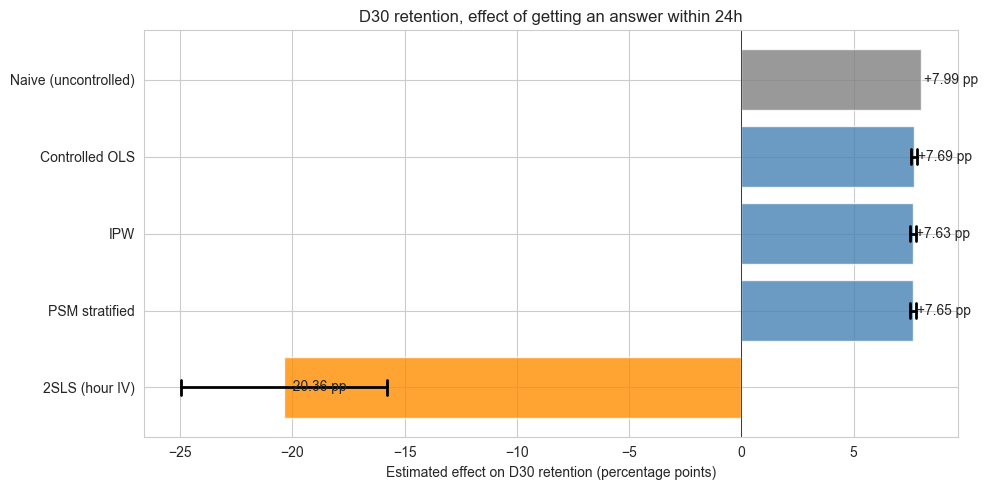

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

methods = summary_d30['method'].tolist()
estimates = summary_d30['estimate_pp'].values
ci_low = summary_d30['ci_low_pp'].values
ci_high = summary_d30['ci_high_pp'].values

y = np.arange(len(methods))
ax.barh(y, estimates, color=['gray', 'steelblue', 'steelblue', 'steelblue', 'darkorange'], alpha=0.8)
for i, (lo, hi) in enumerate(zip(ci_low, ci_high)):
    if not np.isnan(lo):
        ax.plot([lo, hi], [i, i], 'k-', lw=2)
        ax.plot([lo, lo], [i - 0.1, i + 0.1], 'k-', lw=2)
        ax.plot([hi, hi], [i - 0.1, i + 0.1], 'k-', lw=2)

for i, est in enumerate(estimates):
    ax.text(est + 0.15, i, f'{est:+.2f} pp', va='center', fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(methods)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Estimated effect on D30 retention (percentage points)')
ax.set_title('D30 retention, effect of getting an answer within 24h')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. D180 outcome, same four methods

Restricted to the observable subset (users whose first post is at least 210 days before the data snapshot). The same code paths, just with active_d180 as the outcome and a smaller sample.

In [9]:
df_obs = df[df['d180_observable'] == 1].copy()
print(f'D180-observable subset: {len(df_obs):,} rows')

ols_d180 = fit_ols(df_obs, 'active_d180', 'got_answer_within_24h', covariates_full)
ipw_d180 = fit_ipw(df_obs, 'active_d180', 'got_answer_within_24h', covariates_full)
psm_d180 = fit_psm_stratified(df_obs, 'active_d180', 'got_answer_within_24h', ipw_d180['ps'])
iv_d180  = fit_iv2sls(df_obs, 'active_d180', 'got_answer_within_24h', 'hour_instrument_rate', covariates_iv)

naive_d180 = {
    'method': 'Naive (uncontrolled)',
    'estimate_pp': (df_obs.loc[df_obs['got_answer_within_24h']==1, 'active_d180'].mean() -
                    df_obs.loc[df_obs['got_answer_within_24h']==0, 'active_d180'].mean()) * 100,
    'se_pp': np.nan, 'ci_low_pp': np.nan, 'ci_high_pp': np.nan,
    'n': len(df_obs),
}

summary_d180 = pd.DataFrame([naive_d180, ols_d180, ipw_d180, psm_d180, iv_d180])
summary_d180 = summary_d180[['method', 'estimate_pp', 'se_pp', 'ci_low_pp', 'ci_high_pp', 'n']]
print()
print('D180 outcome, treatment-effect estimates across methods:')
print()
print(summary_d180.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if pd.notna(x) else 'NaN'))
print()
print(f'D30 first-stage F: {iv_d30["first_stage_f"]:.1f}')
print(f'D180 first-stage F: {iv_d180["first_stage_f"]:.1f}')

D180-observable subset: 1,531,825 rows



D180 outcome, treatment-effect estimates across methods:

              method  estimate_pp  se_pp  ci_low_pp  ci_high_pp       n
Naive (uncontrolled)        +1.51    NaN        NaN         NaN 1531825
      Controlled OLS        +1.48  +0.04      +1.41       +1.55 1531825
                 IPW        +1.47  +0.04      +1.40       +1.54 1531825
      PSM stratified        +1.47  +0.04      +1.40       +1.54 1531825
      2SLS (hour IV)       -12.57  +1.28     -15.08      -10.06 1531825

D30 first-stage F: 1598.5
D180 first-stage F: 1354.7


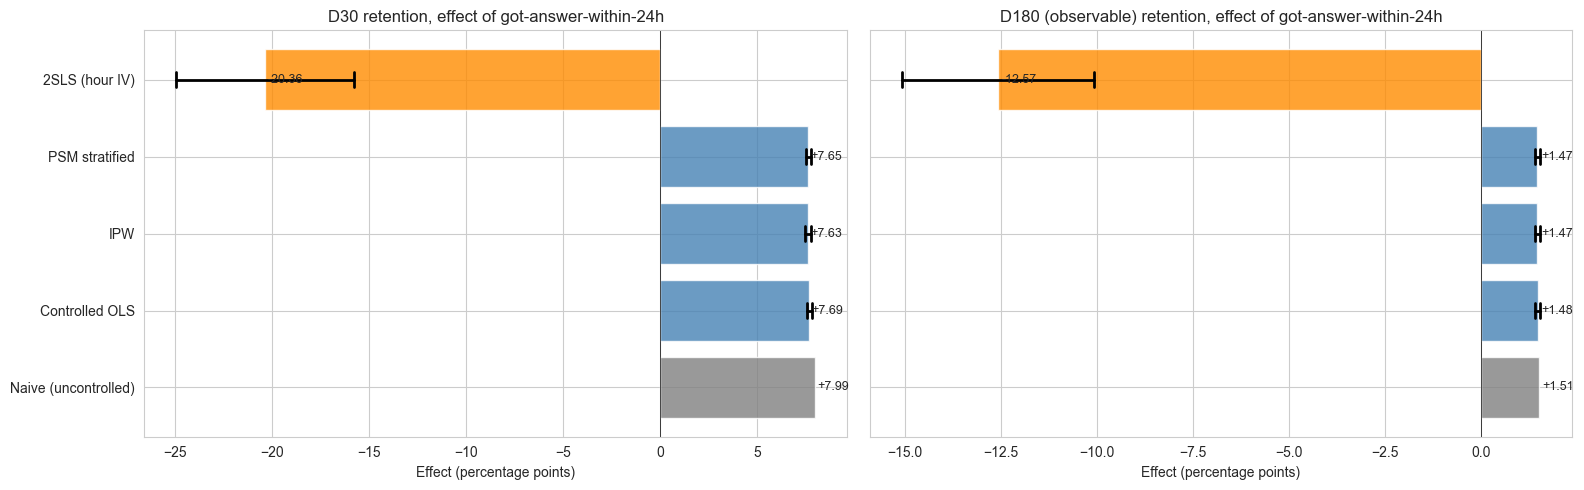

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, summary, label in zip(axes, [summary_d30, summary_d180], ['D30', 'D180 (observable)']):
    methods = summary['method'].tolist()
    estimates = summary['estimate_pp'].values
    ci_low = summary['ci_low_pp'].values
    ci_high = summary['ci_high_pp'].values
    y = np.arange(len(methods))
    colors = ['gray', 'steelblue', 'steelblue', 'steelblue', 'darkorange']
    ax.barh(y, estimates, color=colors, alpha=0.8)
    for i, (lo, hi) in enumerate(zip(ci_low, ci_high)):
        if not np.isnan(lo):
            ax.plot([lo, hi], [i, i], 'k-', lw=2)
            ax.plot([lo, lo], [i - 0.1, i + 0.1], 'k-', lw=2)
            ax.plot([hi, hi], [i - 0.1, i + 0.1], 'k-', lw=2)
    for i, est in enumerate(estimates):
        ax.text(est + 0.1, i, f'{est:+.2f}', va='center', fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(methods)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel('Effect (percentage points)')
    ax.set_title(f'{label} retention, effect of got-answer-within-24h')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Interpretation

What I want to read off these tables, in order of importance.

First, how much does the controlled estimate shrink relative to naive? That's a measure of how much of the raw lift was selection on observable question quality. If the gap between naive and controlled OLS is small, the observable features aren't capturing much of the confounding, and we should be skeptical of any of these estimates.

Second, do IPW and PSM-stratified agree with controlled OLS? They should, roughly, if the propensity model is well-specified. Disagreement suggests the propensity model is missing something the OLS picks up, or vice versa.

Third, where does 2SLS land? It estimates a local average treatment effect, the effect for compliers (users whose treatment status was actually shifted by the hour they posted at). If 2SLS is larger than the regression estimates, that argues for unobserved confounders that bias the regression methods downward. If 2SLS is smaller, either the instrument is weak (check the F-stat) or compliers respond less to treatment than non-compliers.

Fourth, the D30 vs D180 comparison. The naive numbers suggested the answer effect decays sharply over time. If that holds after adjustment, the case-study finding is that getting an answer keeps users alive for a month but doesn't lock in long-term loyalty. That has product implications.

Saving the results table for the dashboard and the writeup.

In [11]:
summary_d30['outcome'] = 'D30'
summary_d180['outcome'] = 'D180'
summary_all = pd.concat([summary_d30, summary_d180], ignore_index=True)
summary_all = summary_all[['outcome', 'method', 'estimate_pp', 'se_pp', 'ci_low_pp', 'ci_high_pp', 'n']]

out_path = f'{DATA_DIR}/treatment_effects.parquet'
summary_all.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')
print()
print(summary_all.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if pd.notna(x) else 'NaN'))

Saved: ../data/processed/treatment_effects.parquet

outcome               method  estimate_pp  se_pp  ci_low_pp  ci_high_pp       n
    D30 Naive (uncontrolled)        +7.99    NaN        NaN         NaN 1772119
    D30       Controlled OLS        +7.69  +0.07      +7.56       +7.82 1772119
    D30                  IPW        +7.63  +0.07      +7.50       +7.76 1772119
    D30       PSM stratified        +7.65  +0.07      +7.52       +7.78 1772119
    D30       2SLS (hour IV)       -20.36  +2.34     -24.95      -15.77 1772119
   D180 Naive (uncontrolled)        +1.51    NaN        NaN         NaN 1531825
   D180       Controlled OLS        +1.48  +0.04      +1.41       +1.55 1531825
   D180                  IPW        +1.47  +0.04      +1.40       +1.54 1531825
   D180       PSM stratified        +1.47  +0.04      +1.40       +1.54 1531825
   D180       2SLS (hour IV)       -12.57  +1.28     -15.08      -10.06 1531825
